## Decision Tree Classification Model(Single Decision Tree)

Building and evaluating a scikit-learn Decision Tree Classifier to predict passenger satisfaction.

### Workflow in this notebook

**Prepared Data**  
↓  
**Scikit-learn Decision Tree Classifier**  
↓  
**5-Fold Cross-Validation**  
↓  
**Untuned Model Evaluation**  
↓  
**Overfitting Check**  
↓  
**GridSearchCV Tuning**  
↓  
**Tuned Model Evaluation**  
↓  
**Untuned vs. Tuned Comparison**  
↓  
**Final Test Evaluation**  
↓  
**Feature Importance**

In [1]:
# Import the libraries needed for data preparation and decision tree classification

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

#### Load prepared data

In [2]:
# Load the prepared training and test datasets created in the preprocessing notebook

train = pd.read_csv("../prepared_data/train_prepared.csv")
test = pd.read_csv("../prepared_data/test_prepared.csv")

print("Training:", train.shape)
print("Test:", test.shape)

Training: (103594, 23)
Test: (25893, 23)


#### Separate Predictors and Target

In [3]:
# Separate the input features (X) from the target variable (y)
# The training data will be used for model development, while the test data is kept for final evaluation

X_train = train.drop(columns=["satisfaction"])
y_train = train["satisfaction"]

X_test = test.drop(columns=["satisfaction"])
y_test = test["satisfaction"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (103594, 22)
y_train: (103594,)
X_test: (25893, 22)
y_test: (25893,)


### Identify and Encode Categorical Variables

In [4]:
# First identify all categorical columns in the training features

categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [5]:
# Convert categorical columns to numbers and keep the other columns unchanged

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

preprocessor

,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


#### Create the Decision Tree Model

In [6]:
# Create one model that first prepares the data, then uses it to train the decision tree

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
# Convert the two satisfaction categories to 0 and 1 for model evaluation

target_mapping = {
    "neutral or dissatisfied": 0,
    "satisfied": 1
}

y_train = y_train.map(target_mapping)
y_test = y_test.map(target_mapping)

print("Target values:", sorted(y_train.unique()))
print("\nTraining target counts:")
print(y_train.value_counts())

Target values: [np.int64(0), np.int64(1)]

Training target counts:
satisfaction
0    58697
1    44897
Name: count, dtype: int64


### 5-Fold Cross-Validation

In [8]:
# Split the training data into 5 folds for repeated training and validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [9]:
# Define the metrics used to evaluate the decision tree during cross-validation

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "sensitivity": "recall",
    "specificity": make_scorer(recall_score, pos_label=0),
    "roc_auc": "roc_auc"
}

print("Metrics:", list(scoring.keys()))

Metrics: ['accuracy', 'precision', 'sensitivity', 'specificity', 'roc_auc']


In [10]:
# Run 5-fold cross-validation and calculate the selected metrics for each fold

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

cv_results

{'fit_time': array([0.5538671 , 0.49696875, 0.49020386, 0.51040339, 0.59866142]),
 'score_time': array([0.04789186, 0.05854297, 0.04572415, 0.04188943, 0.0537827 ]),
 'test_accuracy': array([0.94565375, 0.94319224, 0.94246827, 0.94618466, 0.9462786 ]),
 'test_precision': array([0.93334069, 0.93499108, 0.93276284, 0.93534817, 0.93458564]),
 'test_sensitivity': array([0.94186435, 0.93384564, 0.93463252, 0.9408686 , 0.94197572]),
 'test_specificity': array([0.94855196, 0.95034072, 0.94846239, 0.9502513 , 0.94956981]),
 'test_roc_auc': array([0.94520815, 0.94209318, 0.94154745, 0.94555995, 0.94577277])}

In [11]:
# Organize the 5-fold results into a clear table and calculate the mean and standard deviation

cv_table = pd.DataFrame({
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Sensitivity": cv_results["test_sensitivity"],
    "Specificity": cv_results["test_specificity"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

cv_table.index = [f"Fold {i}" for i in range(1, 6)]

cv_table.loc["Mean"] = cv_table.mean()
cv_table.loc["Std"] = cv_table.iloc[:5].std()

print(cv_table.round(4))

        Accuracy  Precision  Sensitivity  Specificity  ROC-AUC
Fold 1    0.9457     0.9333       0.9419       0.9486   0.9452
Fold 2    0.9432     0.9350       0.9338       0.9503   0.9421
Fold 3    0.9425     0.9328       0.9346       0.9485   0.9415
Fold 4    0.9462     0.9353       0.9409       0.9503   0.9456
Fold 5    0.9463     0.9346       0.9420       0.9496   0.9458
Mean      0.9448     0.9342       0.9386       0.9494   0.9440
Std       0.0018     0.0011       0.0040       0.0009   0.0020


In [12]:
# Save the untuned 5-fold cross-validation results to the checkpoints folder

# Create the checkpoints folder if it does not already exist

checkpoint_dir = Path("../checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / "01_decision_tree_untuned_cv.txt"

with open(checkpoint_path, "w") as file:
    file.write("DECISION TREE - before_tuning 5-FOLD CROSS-VALIDATION\n")
    file.write("=" * 60 + "\n\n")

    file.write("Target classes:\n")
    file.write("0 = neutral or dissatisfied\n")
    file.write("1 = satisfied\n\n")

    file.write("Cross-validation: 5-fold StratifiedKFold\n")
    file.write("Random state: 42\n\n")

    file.write(cv_table.round(4).to_string())
    file.write("\n")

print("Results saved to:", checkpoint_path)

Results saved to: ..\checkpoints\01_decision_tree_untuned_cv.txt


#### Check for Overfitting

In [13]:
# Compare training and validation accuracy to check whether the decision tree is overfitting

overfitting_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

print("Mean training accuracy:",
      round(overfitting_results["train_score"].mean(), 4))

print("Mean validation accuracy:",
      round(overfitting_results["test_score"].mean(), 4))

Mean training accuracy: 1.0
Mean validation accuracy: 0.9448


In [14]:
# Save the training and validation accuracy used to check for overfitting

train_accuracy = overfitting_results["train_score"].mean()
validation_accuracy = overfitting_results["test_score"].mean()

with open("../checkpoints/02_decision_tree_overfitting.txt", "w") as file:
    file.write("DECISION TREE - OVERFITTING CHECK\n")
    file.write("=" * 50 + "\n\n")
    file.write(f"Mean training accuracy:   {train_accuracy:.4f}\n")
    file.write(f"Mean validation accuracy: {validation_accuracy:.4f}\n")
    file.write(f"Difference:               {train_accuracy - validation_accuracy:.4f}\n")

print("Overfitting results saved.")

Overfitting results saved.


#### Tune the Decision Tree

In [15]:
# Try different tree settings to find a model that performs better on unseen data

param_grid = {
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best settings:", grid_search.best_params_)
print("Best validation accuracy:", round(grid_search.best_score_, 4))

Best settings: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 20}
Best validation accuracy: 0.9532


In [16]:
# Evaluate the best tuned decision tree and summarize its 5-fold results

tuned_model = grid_search.best_estimator_

tuned_cv_results = cross_validate(
    tuned_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

tuned_cv_table = pd.DataFrame({
    "Accuracy": tuned_cv_results["test_accuracy"],
    "Precision": tuned_cv_results["test_precision"],
    "Sensitivity": tuned_cv_results["test_sensitivity"],
    "Specificity": tuned_cv_results["test_specificity"],
    "ROC-AUC": tuned_cv_results["test_roc_auc"]
})

tuned_cv_table.index = [f"Fold {i}" for i in range(1, 6)]

tuned_cv_table.loc["Mean"] = tuned_cv_table.mean()
tuned_cv_table.loc["Std"] = tuned_cv_table.iloc[:5].std()

print(tuned_cv_table.round(4))

print("\nMean training accuracy:",
      round(tuned_cv_results["train_accuracy"].mean(), 4))

print("Mean validation accuracy:",
      round(tuned_cv_results["test_accuracy"].mean(), 4))

        Accuracy  Precision  Sensitivity  Specificity  ROC-AUC
Fold 1    0.9540     0.9582       0.9345       0.9688   0.9859
Fold 2    0.9522     0.9643       0.9238       0.9739   0.9822
Fold 3    0.9524     0.9609       0.9280       0.9711   0.9822
Fold 4    0.9550     0.9598       0.9354       0.9700   0.9845
Fold 5    0.9524     0.9536       0.9357       0.9652   0.9817
Mean      0.9532     0.9594       0.9315       0.9698   0.9833
Std       0.0012     0.0039       0.0053       0.0032   0.0018

Mean training accuracy: 0.9681
Mean validation accuracy: 0.9532


In [17]:
# Save the best tree settings and tuned 5-fold cross-validation results

checkpoint_path = "../checkpoints/03_decision_tree_tuned_cv.txt"

with open(checkpoint_path, "w") as file:
    file.write("DECISION TREE - TUNED 5-FOLD CROSS-VALIDATION\n")
    file.write("=" * 60 + "\n\n")

    file.write("Best settings:\n")
    file.write(f"max_depth: {grid_search.best_params_['classifier__max_depth']}\n")
    file.write(f"min_samples_split: {grid_search.best_params_['classifier__min_samples_split']}\n")
    file.write(f"min_samples_leaf: {grid_search.best_params_['classifier__min_samples_leaf']}\n\n")

    file.write("Cross-validation results:\n")
    file.write(tuned_cv_table.round(4).to_string())
    file.write("\n\n")

    file.write("Overfitting check:\n")
    file.write(f"Mean training accuracy:   {tuned_cv_results['train_accuracy'].mean():.4f}\n")
    file.write(f"Mean validation accuracy: {tuned_cv_results['test_accuracy'].mean():.4f}\n")
    file.write(
        f"Difference:               "
        f"{tuned_cv_results['train_accuracy'].mean() - tuned_cv_results['test_accuracy'].mean():.4f}\n"
    )

print("Results saved to:", checkpoint_path)

Results saved to: ../checkpoints/03_decision_tree_tuned_cv.txt


#### Compare Untuned and Tuned Decision Trees

In [18]:
# Compare the untuned and tuned decision trees using their mean cross-validation results

comparison = pd.DataFrame({
    "Untuned": [
        cv_table.loc["Mean", "Accuracy"],
        cv_table.loc["Mean", "Precision"],
        cv_table.loc["Mean", "Sensitivity"],
        cv_table.loc["Mean", "Specificity"],
        cv_table.loc["Mean", "ROC-AUC"],
        overfitting_results["train_score"].mean()
    ],
    "Tuned": [
        tuned_cv_table.loc["Mean", "Accuracy"],
        tuned_cv_table.loc["Mean", "Precision"],
        tuned_cv_table.loc["Mean", "Sensitivity"],
        tuned_cv_table.loc["Mean", "Specificity"],
        tuned_cv_table.loc["Mean", "ROC-AUC"],
        tuned_cv_results["train_accuracy"].mean()
    ]
}, index=[
    "Validation Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "ROC-AUC",
    "Training Accuracy"
])

comparison["Difference"] = comparison["Tuned"] - comparison["Untuned"]

print(comparison.round(4))

                     Untuned   Tuned  Difference
Validation Accuracy   0.9448  0.9532      0.0084
Precision             0.9342  0.9594      0.0252
Sensitivity           0.9386  0.9315     -0.0071
Specificity           0.9494  0.9698      0.0204
ROC-AUC               0.9440  0.9833      0.0393
Training Accuracy     1.0000  0.9681     -0.0319


In [19]:
# Save the comparison between the untuned and tuned decision trees

checkpoint_path = checkpoint_dir / "04_decision_tree_comparison.txt"

with open(checkpoint_path, "w") as file:
    file.write("DECISION TREE - UNTUNED VS TUNED\n")
    file.write("=" * 60 + "\n\n")
    file.write(comparison.round(4).to_string())
    file.write("\n")

print("Results saved to:", checkpoint_path)

Results saved to: ..\checkpoints\04_decision_tree_comparison.txt


#### Final Test Evaluation

In [20]:
# Evaluate the tuned decision tree on the unseen test data

y_pred = tuned_model.predict(X_test)
y_prob = tuned_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred, pos_label=1)
specificity = recall_score(y_test, y_pred, pos_label=0)
roc_auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:   ", round(accuracy, 4))
print("Precision:  ", round(precision, 4))
print("Sensitivity:", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))
print("ROC-AUC:    ", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(cm)

Accuracy:    0.9556
Precision:   0.9629
Sensitivity: 0.9348
Specificity: 0.9718
ROC-AUC:     0.9847

Confusion Matrix:
[[14119   409]
 [  741 10624]]


In [21]:
# Save the final test results and confusion matrix

checkpoint_path = checkpoint_dir / "05_decision_tree_final_test.txt"

with open(checkpoint_path, "w") as file:
    file.write("DECISION TREE - FINAL TEST EVALUATION\n")
    file.write("=" * 60 + "\n\n")

    file.write(f"Accuracy:    {accuracy:.4f}\n")
    file.write(f"Precision:   {precision:.4f}\n")
    file.write(f"Sensitivity: {sensitivity:.4f}\n")
    file.write(f"Specificity: {specificity:.4f}\n")
    file.write(f"ROC-AUC:     {roc_auc:.4f}\n\n")

    file.write("Confusion Matrix:\n")
    file.write("                     Predicted\n")
    file.write("                     0       1\n")
    file.write(f"Actual 0          {cm[0,0]:5d}   {cm[0,1]:5d}\n")
    file.write(f"Actual 1          {cm[1,0]:5d}   {cm[1,1]:5d}\n\n")

    file.write("0 = neutral or dissatisfied\n")
    file.write("1 = satisfied\n")

print("Results saved to:", checkpoint_path)

Results saved to: ..\checkpoints\05_decision_tree_final_test.txt


#### Feature Importance

                           Feature  Importance
16                 Online boarding      0.3976
11           Inflight wifi service      0.1953
4   Type of Travel_Business travel      0.1449
18          Inflight entertainment      0.0500
2     Customer Type_Loyal Customer      0.0392
22                 Checkin service      0.0259
6                   Class_Business      0.0224
14                   Gate location      0.0192
5   Type of Travel_Personal Travel      0.0163
17                    Seat comfort      0.0129


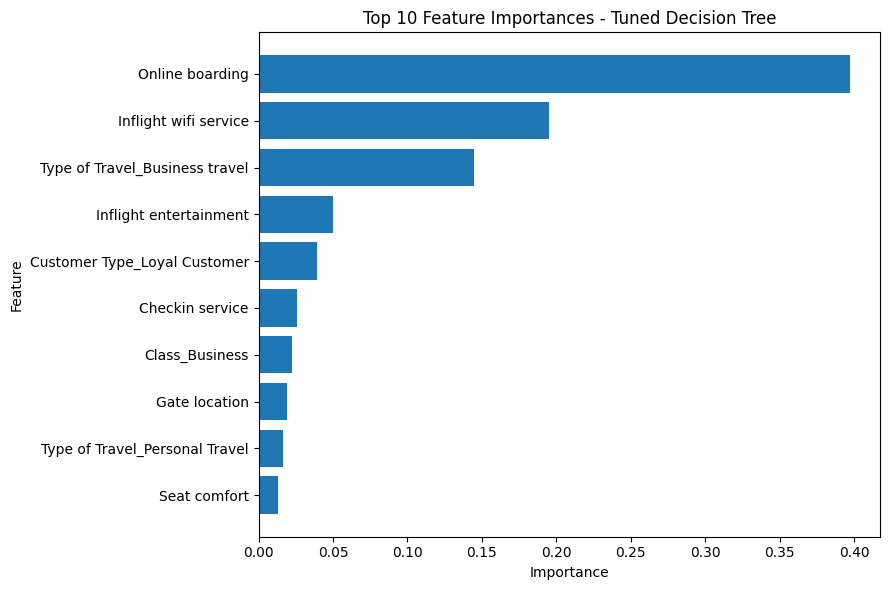

In [22]:
# Calculate, display, and plot the 10 most important features used by the tuned decision tree

feature_names = tuned_model.named_steps["preprocessor"].get_feature_names_out()
importances = tuned_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

print(feature_importance.head(10).round(4))

top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [23]:
# Save the final trained Decision Tree pipeline so it can be used by the Streamlit app

from pathlib import Path
import pickle

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

with open(model_dir / "decision_tree_model.pkl", "wb") as f:
    pickle.dump(tuned_model, f)

print("Saved: models/decision_tree_model.pkl")

Saved: models/decision_tree_model.pkl
